# Similarity processing using text embedder

Here I try and use a text embedder to build to compare the semantic content of sentences that are used in validated questionnaire to measure a particular mode of pain worry often called catastrophising.

## Aim:

* Discover latent semantic dimensions within pain catastrophizing statements
* Identify representative statements for each latent semantic dimension
* Explore the application of these semantic dimensions quantify the semantic distance between the explicit content a sentence and identified latent semantic clusters

## Data Flow Architecture

Embedding Generation → Dimensionality Reduction → Clustering → Analysis/Classification 

Here I will use a common sentence-transformers/all-MiniLM-L6-v2 (there are larger and more sophisticated text-embedders out there). The text embedder will extract text embedding from 50 items used in popular validated catastrophizing scales (these will be my reference statemens). . The text embedder will extract a dense (350+) vector space of characteristics for each reference sentence, I will then reduce the dimensionality of these embeddings and then I will cluster the reduced embeddings using an hierarchical clustering method (agglomerativeclustering). 


## Key Components
* Sentence Embeddings: Using all-MiniLM-L6-v2 to capture semantic meaning in catastrophizing statements
* UMAP Reduction: Compressing 384-dimensional embeddings to 40 dimensions while preserving semantic relationships
* Hierarchical Clustering: Grouping similar statements using agglomerative clustering with cosine similarity
* Cluster Optimization: Using multiple metrics (silhouette, Davies-Bouldin, elbow method) to determine ideal cluster count
* New Text Analysis: Framework for analyzing fresh text against established catastrophizing clusters
   

In [1]:
## list of Pain Catastrophizing Scale items - I will use this as a conceptual reference for catastrophizing
catastrophizing_PCS = [
    "I worry all the time about whether the pain will end",
    "I feel I can't go on with this pain",
    "The pain is terrible and I think it's never going to get any better",
    "The pain is awful and I feel that it overwhelms me",
    "I feel I can't stand pain anymore",
    "I become afraid that the pain will get worse",
    "I keep thinking of other painful events",
    "I anxiously want the pain to go away",
    "I can't seem to keep the pain out of my mind",
    "I keep thinking about how much the pain hurts", 
    "I keep thinking about how badly I want the pain to stop",
    "There's nothing I can do to reduce the intensity of the pain",
    "Because of the pain I worry that something serious may happen"
]

#https://pmc.ncbi.nlm.nih.gov/articles/PMC7060750/
catastrophizing_references = [
	"When I become aware of my pain, this thought comes through my head: 'I can't have a tumour, can I?'",
	"When I become aware of my pain, this thought comes through my head: 'I wonder if I have the same serious illness as..'",
	"When I become aware of my pain, this thought comes through my head: 'it isn't a serious illness, is it?'",
	"When I feel pain I feel like I just want to get up and run away",
	"When I feel pain I begin thinking of all the possible bad things that could go wrong in association with the pain",
	"When I feel pain I find myself worrying about possibly dying",
	"When I feel pain I find myself expecting the worst",
	"When I feel pain I tend to think that my pain is pretty awful",
	"When I feel pain I can't help but concentrate on how bad the pain actually feels",
	"When I feel pain I find it virtually impossible to keep my mind off of my pain and how bad it hurts",
	"When I feel pain I begin to worry that something might be seriously wrong with me",
	"When I feel pain, I feel my life isn't worth living",
	"When I'm in pain, I worry all the time about whether the pain will end",
	"When I'm in pain, I feel I can't go on",
	"When I'm in pain, it's terrible and I think it's never going to get any better",
	"When I'm in pain, it's awful and I feel that it overwhelms me",
	"When I'm in pain, I feel I can't stand it anymore",
	"When I'm in pain, I become afraid that the pain will get worse",
	"When I'm in pain, I keep thinking of other painful events",
	"When I'm in pain, I anxiously want the pain to go away",
	"When I'm in pain, I can't seem to keep it out of my mind",
	"When I'm in pain, I keep thinking about how much it hurts",
	"When I'm in pain, I keep thinking about how badly I want the pain to stop",
	"When I'm in pain, there's nothing I can do to reduce the intensity of the pain",
	"When I'm in pain, I wonder whether something serious may happen",
	"I often think back to the days when I had no pain",
	"I focus on the pain all the time",
	"Beacuse of the pain I consider myself an unlucky person",
	"Beacuse of the pain I think that fate has caught up with me",
	"Beacuse of the pain The word pain frightens me",
	"Beacuse of the pain I often think: 'Why is this happening to me?'",
	"I think that, because of the pain, I have changed my view of life",
	"I feel powerless against the pain",
	"Beacuse of the pain I think I am always very tense",
	"Beacuse of the pain I make sure I protect myself from extra pain",
	"Beacuse of the pain I have become less able mentally",
	"Beacuse of the pain I consider myself to be a hopeless case",
	"When the pain is very strong I get furious",
	"I sometimes wonder how other people cope with severe pain",
	"I cannot live without pain-killers",
	"I am disappointed in myself for giving in to the pain",
	"I cannot stand this pain any longer",
	"No matter what I do, my pain doesn't change anyway",
	"I need to take some pain medication",
	"Havin pain will never end",
	"Beacuse of the pain I am a hopeless case",
	"When will the pain get worse again?",
	"This pain is killing me",
	"Beacuse of the pain I can't go on anymore",
	"This pain drives me crazy",    
]

In [2]:
# this is a basic sentence tokenizer - it simply does sentece splitting - no fancy linguistic processing

import nltk ## need pip install nltk
nltk.download("punkt_tab") # in case you do not have that already


[nltk_data] Downloading package punkt_tab to /home/diego/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## STEP1:  Get embeddings

Here we converts our 50 catoastrophizing sentences into a high dimensional space of numberic vectors using a SentenceTransformer (in this case (all-MiniLM-L6-v2)

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
ref_embeddings= model.encode(catastrophizing_references)




2025-04-28 12:58:07.806875: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-28 12:58:07.806936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-28 12:58:07.808859: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-28 12:58:07.823473: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-28 12:58:09.495010: W tensorflow/compiler/tf2

In [4]:
ref_embeddings.shape

(50, 384)

## STEP2: reduce embedding dimensionality

Reduce embedding dimensions while preserving semantic relationships.



In [5]:
# dimensionality reduction with UMAP
import umap.umap_ as umap
import umap.plot

reducer = umap.UMAP(
    # https://umap-learn.readthedocs.io/en/latest/parameters.html
    n_components=15,        # Target dimensionality
    n_neighbors=15,         # Local neighborhood size
    min_dist=0.2,           # Minimum distance between points
    metric='cosine',        # Distance metric for semantic embeddings
    random_state=42         # For reproducibility
)

ref_embeddings_reduced = reducer.fit_transform(ref_embeddings)  
ref_embeddings_reduced.shape


/home/diego/CRIISP-WP6/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(50, 15)

## STEP3 Hierarchical clustering

Here we group similar catastrophizing statements to identify distinct semantic patterns and themes.



### STEP3.1 Find optimal clustering dimensions

In [6]:

def find_optimal_hierarchical_clusters(embeddings, max_clusters, linkage_method):
  
    # Normalize embeddings for metrics that need Euclidean distance
    normalized_embeddings = embeddings / np.linalg.norm(embeddings, axis=1)[:, np.newaxis]

    # Metrics storage
    silhouette_scores = []
    davies_bouldin_scores = []
    inertia_scores = []

    # Calculate metrics for different numbers of clusters
    for n_clusters in range(2, max_clusters + 1):
        # Handle different linkage methods
        if linkage_method == 'ward':
            clustering = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage='ward'
            )
            labels = clustering.fit_predict(normalized_embeddings)
        else:
            clustering = AgglomerativeClustering(
                n_clusters=n_clusters,
                metric='cosine',
                linkage=linkage_method
            )
            labels = clustering.fit_predict(embeddings)

        # Calculate silhouette score
        # range [-1,1] with:
        #  zero indicating overlapping factors, 
        # -1 as incorrect clustering and
        silhouette_scores.append(silhouette_score(embeddings, labels, metric='cosine'))

        # Calculate Davies-Bouldin score using normalized embeddings
        # minimum score is zero with values close to zero indicating better partition
        davies_bouldin_scores.append(davies_bouldin_score(normalized_embeddings, labels))

        # Calculate inertia (WCSS)
        wcss = 0
        for i in range(n_clusters):
            mask = labels == i
            if np.any(mask):
                # Calculate centroid
                centroid = np.mean(embeddings[mask], axis=0)
                # Calculate distances to centroid
                distances = 1 - cosine_similarity(embeddings[mask], [centroid])
                wcss += np.sum(distances)
        inertia_scores.append(wcss)

    # Find optimal number of clusters
    sil_optimal = np.argmax(silhouette_scores) + 2
    db_optimal = np.argmin(davies_bouldin_scores) + 2

    # Elbow method: Find the "elbow" point using the second derivative
    second_diffs = np.diff(np.diff(inertia_scores))
    elbow_optimal = np.argmax(second_diffs) + 3  # +3 due to double diff and starting at 2

    # Create consensus optimal cluster number
    all_optimals = [sil_optimal, db_optimal, elbow_optimal]
    consensus_optimal = max(set(all_optimals), key=all_optimals.count)

    # Create visualization plots
    fig = plt.figure(figsize=(15, 15))

    # Plot 1: Dendrogram
    ax1 = plt.subplot(3, 1, 1)
    # Use consistent linkage method for dendrogram
    if linkage_method == 'ward':
        linkage_matrix = linkage(normalized_embeddings, method='ward')
    else:
        linkage_matrix = linkage(embeddings, method=linkage_method, metric='cosine')
    dendrogram(linkage_matrix, ax=ax1)
    ax1.set_title('Hierarchical Clustering Dendrogram')
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Distance')

    # Plot 2: Validation metrics
    ax2 = plt.subplot(3, 1, 2)
    x_range = range(2, max_clusters + 1)
    ax2.plot(x_range, silhouette_scores, label='Silhouette Score', marker='o')
    ax2.plot(x_range, davies_bouldin_scores, label='Davies-Bouldin Score', marker='s')
    ax2.axvline(x=sil_optimal, color='r', linestyle='--', label=f'Silhouette Optimal: {sil_optimal}')
    ax2.axvline(x=db_optimal, color='g', linestyle='--', label=f'Davies-Bouldin Optimal: {db_optimal}')
    ax2.axvline(x=consensus_optimal, color='k', linestyle='-', label=f'Consensus: {consensus_optimal}')
    ax2.set_xlabel('Number of Clusters')
    ax2.set_ylabel('Score')
    ax2.legend()
    ax2.set_title('Clustering Validation Metrics')

    # Plot 3: Elbow method
    ax3 = plt.subplot(3, 1, 3)
    ax3.plot(x_range, inertia_scores, marker='o', label='WCSS')
    ax3.axvline(x=elbow_optimal, color='b', linestyle='--', label=f'Elbow Optimal: {elbow_optimal}')
    ax3.axvline(x=consensus_optimal, color='k', linestyle='-', label=f'Consensus: {consensus_optimal}')
    ax3.set_title('Elbow Method')
    ax3.set_xlabel('Number of Clusters')
    ax3.set_ylabel('Within-Cluster Sum of Squares')
    ax3.legend()

    plt.tight_layout()
    plt.show()

    # Return detailed results
    return {
        'silhouette_optimal': sil_optimal,
        'davies_bouldin_optimal': db_optimal,
        'elbow_optimal': elbow_optimal,
        'consensus_optimal': consensus_optimal,
        'consensus_range': (min(all_optimals), max(all_optimals)),
        'metrics': {
            'silhouette_scores': silhouette_scores,
            'davies_bouldin_scores': davies_bouldin_scores#,
            #'inertia_scores': inertia_scores
        }#,
        #'linkage_matrix': linkage_matrix
    }


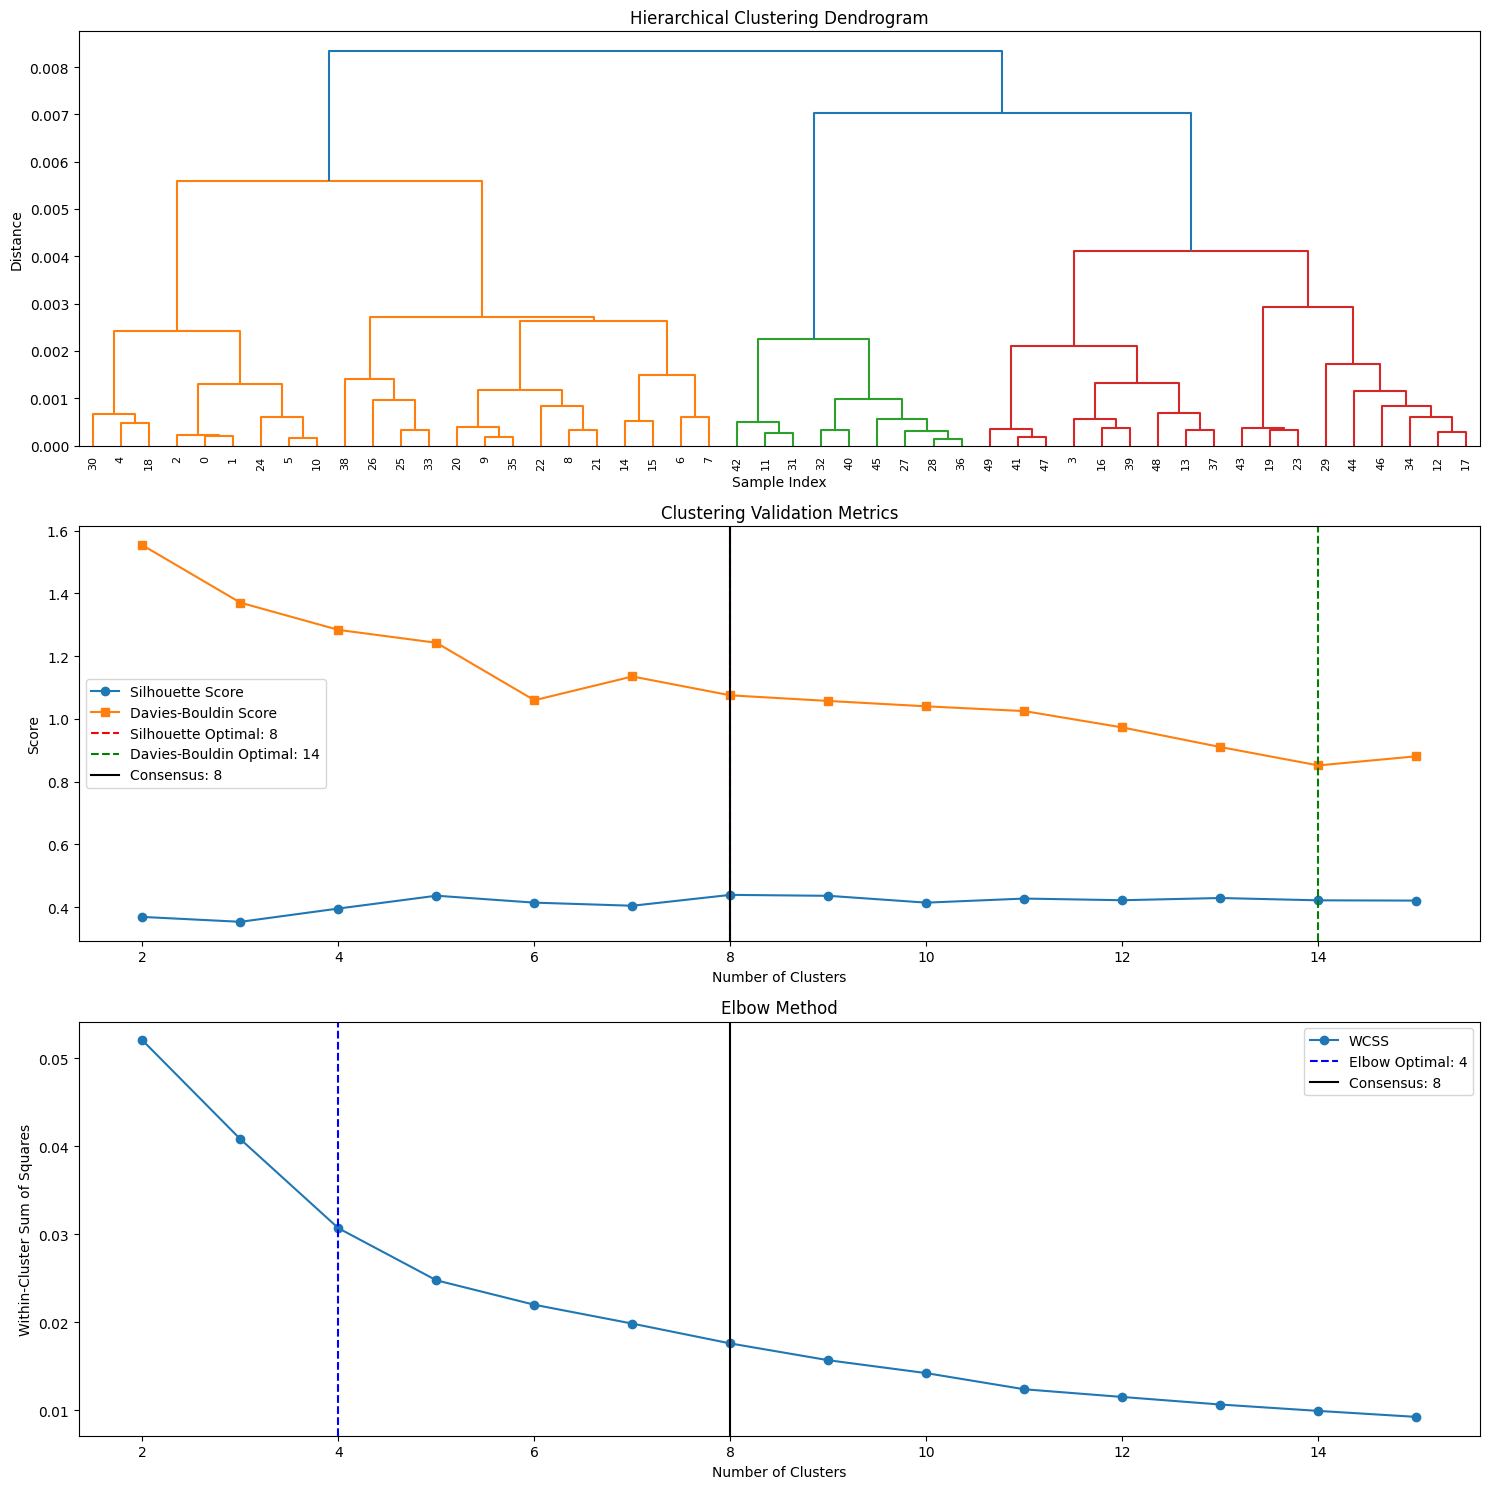

{'silhouette_optimal': 8,
 'davies_bouldin_optimal': 14,
 'elbow_optimal': 4,
 'consensus_optimal': 8,
 'consensus_range': (4, 14),
 'metrics': {'silhouette_scores': [0.36884075,
   0.35327092,
   0.39559627,
   0.43643147,
   0.41437295,
   0.404464,
   0.43910453,
   0.43610454,
   0.41434303,
   0.4273571,
   0.42203864,
   0.42910463,
   0.42171618,
   0.42090833],
  'davies_bouldin_scores': [1.5531692364908631,
   1.3701749720751286,
   1.2834388956707719,
   1.2423415915133256,
   1.05933402100028,
   1.13504783362186,
   1.0749213373548248,
   1.0570097136186452,
   1.0398620917729737,
   1.0247289594368523,
   0.9726067664444793,
   0.9101846972587564,
   0.851605200612782,
   0.8806994099717204]}}

In [7]:
## using agglomerativeclustering
find_optimal_hierarchical_clusters(ref_embeddings_reduced, 
                                   linkage_method= "complete",
                                   max_clusters=15)

## STEP3.2: Hierarchical Clustering

1. Performs hierarchical clustering to group similar references
2. Identifies the most representative (central) sentence for each cluster
3. Calculates cluster cohesion through average within-cluster similarity


In [8]:
def analyze_semantic_clusters(embeddings, references, n_clusters, linkage):
   
    # Handle clustering based on linkage method
    if linkage == 'ward':
        # Ward requires Euclidean distance
        normalized_embeddings = embeddings / np.linalg.norm(embeddings, axis=1)[:, np.newaxis]
        clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
        clusters = clustering.fit_predict(normalized_embeddings)
    else:
        # Use cosine for other linkage methods
        clustering = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric='cosine',
            linkage=linkage
        )
        clusters = clustering.fit_predict(embeddings)

    # Verification step
    print(f"Number of references: {len(references)}")
    print(f"Unique cluster labels: {np.unique(clusters)}")
    print(f"Cluster sizes: {np.bincount(clusters)}")

    # Group references by cluster and find central reference for each cluster
    clustered_refs = {}
    for cluster_id in range(n_clusters):
        cluster_mask = clusters == cluster_id
        cluster_embeddings = embeddings[cluster_mask]
        cluster_sentences = np.array(references)[cluster_mask]

        # Verify we have sentences in this cluster
        if len(cluster_sentences) == 0:
            print(f"Warning: Cluster {cluster_id} is empty!")
            continue

        # Find the most central sentence in cluster
        within_similarities = cosine_similarity(cluster_embeddings)
        centrality_scores = within_similarities.mean(axis=1)
        central_idx = centrality_scores.argmax()

        clustered_refs[cluster_id] = {
            'sentences': cluster_sentences.tolist(),
            'central_sentence': cluster_sentences[central_idx],
            'size': len(cluster_sentences),
            'average_similarity': within_similarities.mean()
        }

    return clustered_refs, clusters

In [9]:

# Analyze clusters (uses agglomerativeclustering)
semantic_clusters, cluster_labels = analyze_semantic_clusters(ref_embeddings_reduced, 
                                                              references=catastrophizing_references,
                                                              n_clusters = 5,
                                                              linkage = "complete") # "ward","complete","average"


Number of references: 50
Unique cluster labels: [0 1 2 3 4]
Cluster sizes: [ 9 14  9  9  9]


## STEP 3.2.1 Hierarchical Clustering diagnostics

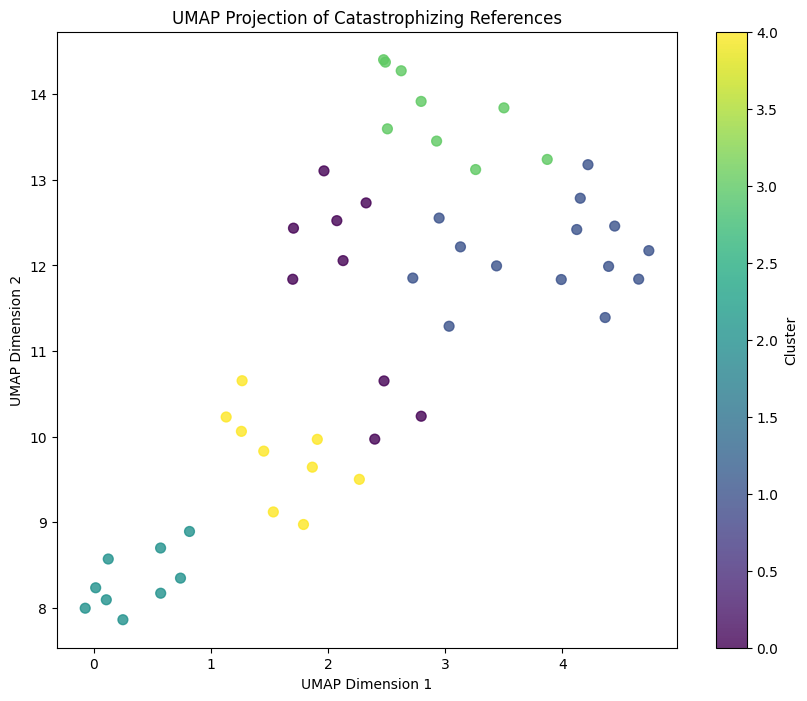

In [10]:
# 2D charting
# First run your dimensionality reduction with UMAP
import umap.umap_ as umap
reducer2D = umap.UMAP(n_components=2)
reduced2D = reducer2D.fit_transform(ref_embeddings_reduced)  # Use the same embeddings as in your clustering

# Then create your scatter plot using the cluster_labels from your function
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    reduced2D[:, 0],
    reduced2D[:, 1],
    c=cluster_labels,  # Use cluster_labels from your function
    cmap='viridis',
    alpha=0.8,
    s=50
)

# Add colorbar and labels
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP Projection of Catastrophizing References')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()


In [11]:
# SILHOUETTE SCORE
from sklearn.metrics import silhouette_score, davies_bouldin_score
silhouette_score(ref_embeddings_reduced, cluster_labels)
# The best value is 1 and the worst value is -1. 
# Values near 0 indicate overlapping clusters. 
# Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar.

0.264962

## STEP 3.2.2 CLUSTERING RESULTS WITH CENTRAL STATEMENTS

In [12]:

# Print results with verification
print("\nSemantic Clusters in Catastrophizing References:")
total_sentences = 0
for cluster_id, cluster_info in semantic_clusters.items():
    total_sentences += cluster_info['size']
    print(f"\nCluster {cluster_id + 1} ({cluster_info['size']} statements)")
    print(f"Average within-cluster similarity: {cluster_info['average_similarity']:.3f}")
    print(f"Central statement: {cluster_info['central_sentence']}")
    print("\nOther statements in cluster:")
    for sent in cluster_info['sentences']:
        if sent != cluster_info['central_sentence']:
            print(f"- {sent}")

print(f"\nTotal sentences allocated: {total_sentences}")
print(f"Original number of sentences: {len(catastrophizing_references)}")

# Verify all sentences are included
all_clustered_sentences = set()
for cluster_info in semantic_clusters.values():
    all_clustered_sentences.update(cluster_info['sentences'])

missing_sentences = set(catastrophizing_references) - all_clustered_sentences
if missing_sentences:
    print("\nMissing sentences:")
    for sent in missing_sentences:
        print(f"- {sent}")


Semantic Clusters in Catastrophizing References:

Cluster 1 (9 statements)
Average within-cluster similarity: 0.999
Central statement: When I'm in pain, I anxiously want the pain to go away

Other statements in cluster:
- When I'm in pain, I worry all the time about whether the pain will end
- When I'm in pain, I become afraid that the pain will get worse
- When I'm in pain, there's nothing I can do to reduce the intensity of the pain
- Beacuse of the pain The word pain frightens me
- Beacuse of the pain I make sure I protect myself from extra pain
- I need to take some pain medication
- Havin pain will never end
- When will the pain get worse again?

Cluster 2 (14 statements)
Average within-cluster similarity: 0.999
Central statement: When I feel pain I can't help but concentrate on how bad the pain actually feels

Other statements in cluster:
- When I feel pain I find myself expecting the worst
- When I feel pain I tend to think that my pain is pretty awful
- When I feel pain I find